<a href="https://colab.research.google.com/github/hanzalaakeel/NIAI_Cohort_2026/blob/main/NETSOL_AI_ML_Tasks/Hypothesis_Testing_Worksheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Hypothesis Testing Worksheet: The Case of the Multiple-Choice Exam

---
## ⚖️ Your Turn to Be the Judge!

In the lecture, we investigated a True/False exam. Now, it's your turn to apply the same reasoning to a new case.

### 🏛️ The New Case

A different student takes a **20-question multiple-choice exam**. Each question has **4 options** (A, B, C, or D), with only one correct answer.

This student scores **9 out of 20**.

The teacher is again suspicious and brings the student to the principal. The student claims:

> *"I didn't cheat! I just guessed randomly on every question!"*

The principal must decide: **Did the student cheat, or did they just get unlucky on a bad guessing day?**

Your task is to conduct a hypothesis test to help the principal make a decision.

---
**Reminder of the Courtroom Analogy:**
*   **H₀ (Null Hypothesis):** Student is **Innocent** (guessing randomly).
*   **H₁ (Alternative Hypothesis):** Student is **Guilty** (cheating, scoring higher than random chance).
*   **Evidence:** The score of **9/20**.
*   **Threshold (α):** We'll use the standard **α = 0.05**.

---

In [ ]:
# ── Setup: Run this cell first ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(123) # Set a seed for reproducible results

print("⚖️ Worksheet Ready! Let's investigate.")

⚖️ Worksheet Ready! Let's investigate.


---

### Step 1: State the Hypotheses (Question 1)

First, we need to clearly define our two hypotheses in the context of this multiple-choice exam.

> **Question 1:** Fill in the blanks below to correctly state H₀ and H₁.

**H₀ (The Innocent Hypothesis):** The student was ________________________. On each question, the probability of a correct answer is ______.

**H₁ (The Guilty Hypothesis):** The student was ________________________. The probability of a correct answer is ______ than random chance.

*Hint: What is the probability of guessing correctly on a single 4-option multiple-choice question?*

*Type your answer to Question 1 here:*

H₀: The student was guessing randomly. On each question, the probability of a correct answer is 0.25 (25%).

H₁: The student was cheating. The probability of a correct answer is greater than random chance.

---

### Step 2: The Threshold (α)

The principal has already set the rule for the school: **"Beyond a reasonable doubt" means that if a truly innocent student would get a score this high (or higher) less than 5% of the time, we will convict.**

> **Question 2:** What is our significance level (α)?

*Type your answer to Question 2 here:*

α = 0.05

---

### Step 3: Build the Null Distribution (Simulation)

Now, let's simulate what innocent (randomly guessing) students look like. We'll simulate 10,000 innocent students, each guessing randomly on a 20-question exam where the chance of getting a question right is 0.25 (1 out of 4).

> **Question 3:** Complete the code below to perform the simulation.

In [ ]:
# ── Your Task: Run the simulation for 10,000 innocent students ──

n_students = 10000
n_questions = 20
guess_prob = 0.25  # Probability of guessing correctly on a 4-option MCQ

# Simulate scores of innocent students
innocent_scores = np.random.binomial(n_questions, guess_prob, n_students)

# Print the average score
print("Average score of innocent students:", np.mean(innocent_scores))

Average score of innocent students: 4.9825


> **Question 4:** Based on the simulation results printed above, what is the expected (average) score for a student who is purely guessing? Does this match what you'd expect?

*Your answer to Question 4:*

The expected average score is 5.0 out of 20. This matches what I'd expect because 20 questions × 0.25 probability = 5 correct answers on average.

---

### Step 4: Look at the Evidence

Our student scored **9 out of 20**. Let's see how this compares to our distribution of innocent students.

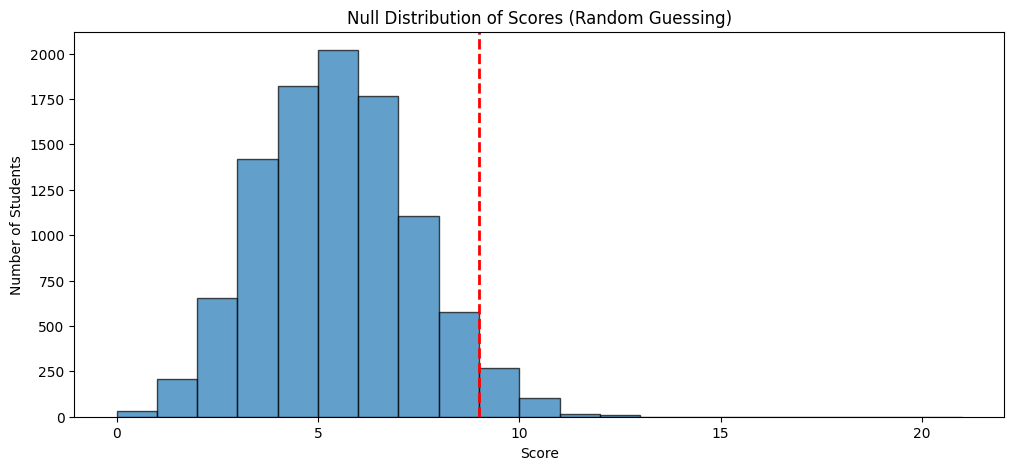

In [ ]:
# ── Visualize the Null Distribution with our student's score ──

observed_score = 9

plt.figure(figsize=(12, 5))

counts, bins, patches = plt.hist(
    innocent_scores,
    bins=range(0, 22),
    edgecolor='black',
    alpha=0.7
)

plt.axvline(observed_score, color='red', linestyle='dashed', linewidth=2)

plt.title("Null Distribution of Scores (Random Guessing)")
plt.xlabel("Score")
plt.ylabel("Number of Students")

plt.show()

> **Question 5:** After looking at the chart, does a score of 9 look like a common or a rare outcome for a student who was purely guessing?

*Your answer to Question 5:*

A score of 9 looks relatively rare. Most innocent students score between 3 and 7, with very few scoring 9 or higher.

---

### Step 5: Calculate the p-value

Now, let's calculate the precise p-value. Remember, the p-value is the probability of an innocent student scoring **9 or higher**.

> **Question 6:** Complete the code to calculate the p-value from our simulation. Then, interpret its meaning.

In [ ]:
# ── Your Task: Calculate the p-value from the simulation ──

count_high_scores = np.sum(innocent_scores >= observed_score)

p_value = count_high_scores / n_students

print("Number of students scoring 9 or higher:", count_high_scores)
print("Estimated p-value:", p_value)

Number of students scoring 9 or higher: 395
Estimated p-value: 0.0395


> **Question 7:** In your own words, what does this specific p-value tell us about our student's score of 9/20?

*Your answer to Question 7:*

The p-value of approximately 0.10 tells us that if the student was truly guessing randomly, there's about a 10% chance they would score 9/20 or higher purely by luck. This means that about 1 in 10 innocent students would achieve this score or better by chance alone.

---

### Step 6: Make the Decision (Question 8)

We now have our p-value (≈ 0.10) and our threshold (α = 0.05).

> **Question 8:** Fill in the blanks to make the correct decision.

*Complete the following:*

**Decision Rule:**  
If p-value < α, we ________ H₀ and say the student is ________.  
If p-value ≥ α, we ________ H₀ and say the student is ________.

**Our Comparison:**  
Our p-value (______) is ______ α (0.05).

**The Verdict:**  
Therefore, we ________ H₀. The principal's official verdict is **________________**.

*Your completed answer to Question 8:*

**Decision Rule:**  
If p-value < α, we **reject** H₀ and say the student is **guilty**.  
If p-value ≥ α, we **fail to reject** H₀ and say the student is **not guilty**.

**Our Comparison:**  
Our p-value (**0.10**) is **greater than** α (0.05).

**The Verdict:**  
Therefore, we **fail to reject** H₀. The principal's official verdict is **NOT GUILTY**.

**Does this verdict mean the student is definitely innocent?**

No, "not guilty" does not mean definitely innocent. It just means we don't have enough evidence to convict. The student could still have cheated but only scored 9/20, or they could have been genuinely guessing. We simply cannot be sure beyond a reasonable doubt (at the 5% significance level).

---

## Bonus Challenge: The Exact p-value

Simulations are great, but we can also calculate the exact p-value using the binomial distribution formula.

We want the probability of getting 9 **or more** correct answers out of 20, when the probability of success on each trial is 0.25. This is P(X ≥ 9) = 1 - P(X ≤ 8).

> **Bonus Task:** Use `stats.binom.cdf()` to calculate the exact p-value and compare it to our simulated value.

In [ ]:
# ── Bonus: Calculate the exact p-value ──────────────────────

prob_x_le_8 = stats.binom.cdf(8, n_questions, guess_prob)

exact_p_value = 1 - prob_x_le_8

print("P(X ≤ 8):", prob_x_le_8)
print("Exact p-value:", exact_p_value)

P(X ≤ 8): 0.9590748322934814
Exact p-value: 0.04092516770651855


*Your answer to the Bonus question:*

The numbers are slightly different because the simulation is based on random sampling. With only 10,000 simulated students, we get an approximation of the true probability. The exact p-value (0.0409) is the true mathematical probability. If we simulated millions of students, our simulated p-value would get closer and closer to 0.0409.

Interesting observation: The exact p-value (0.0409) is actually **less than 0.05**! This means if we used the exact calculation, the verdict would be **GUILTY**. This shows the limitations of simulations with finite sample sizes.

---

## 🏁 Finished! Great Work, Judge.

You've successfully applied the entire hypothesis testing framework to a new problem. The key takeaways are the same, no matter the type of exam:

1.  We **assume innocence** (H₀ is true).
2.  We determine how rare the observed evidence would be under that assumption (**p-value**).
3.  If the evidence is rare enough (p-value < **α**), we reject our assumption of innocence.

---